In [2]:
%load_ext autoreload
%autoreload 2

import src.SHAP_like_graph_tool as gp

import networkx as nx
import html
import io
import numpy as np
import shap

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/Users/bgdu69/miniconda3/envs/stageM2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Graphe chargé : 3363 nœuds et 13547 liens.
 Analyse SHAP chargée avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer.joblib
 Nombre d'échantillons : 5419
 Nombre de features : 19


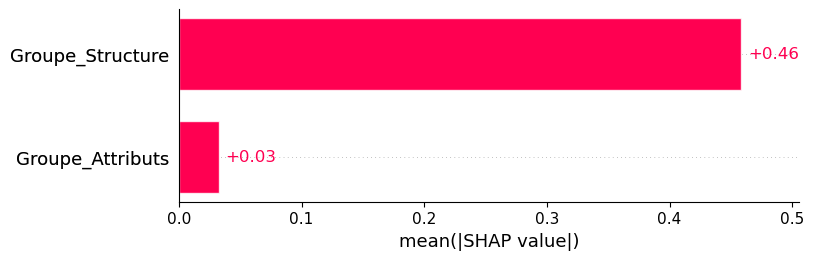

ancienne explanation


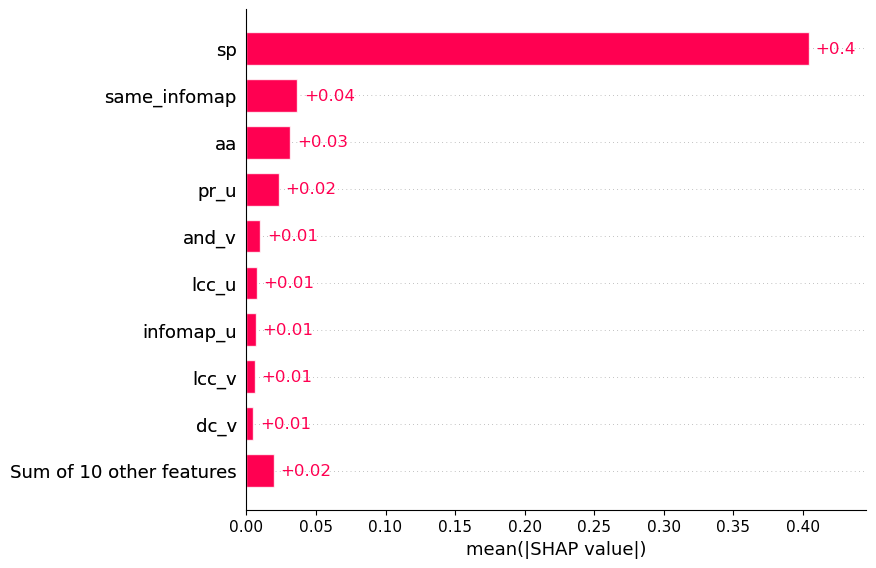

In [14]:
def load_graphml_safe(path):
        with open(path, 'r', encoding='utf-8') as f:
            raw_data = f.read()

        clean_data = html.unescape(raw_data)
        G = nx.read_graphml(io.StringIO(clean_data))
        
        print(f"✅ Graphe chargé : {G.number_of_nodes()} nœuds et {G.number_of_edges()} liens.")
        return G

G = load_graphml_safe("Airports.graphml")

## Import des shap values
shap_exp = gp.utils.load_shap_analysis()

groupes = {
    "Groupe_Structure": ['cn', 'aa', 'jc', 'pa', 'sp', 'pr_u', 'pr_v', 'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u', 'dc_v'],
    "Groupe_Attributs": ['community_u', 'community_v', 'same_community', 'infomap_u', 'infomap_v', 'same_infomap']
}

group_indices = [
    [shap_exp.feature_names.index(f) for f in features_du_groupe]
    for features_du_groupe in groupes.values()
]

new_shap_values = np.array([
    shap_exp.values[:, indices].sum(axis=1) for indices in group_indices
]).T

new_exp = shap.Explanation(
    values=new_shap_values,
    base_values=shap_exp.base_values,
    data=None, # Les données brutes groupées (optionnel)
    feature_names=list(groupes.keys())
)

shap.plots.bar(new_exp)

print("ancienne explanation")
shap.plots.bar(shap_exp)

In [10]:
gp.execute(G,"Airports")

Validation du Graphe terminée. Lancement des calculs...
Graphe original: 13547 liens
Graphe d'entraînement: 11514 liens
Liens cachés pour le test: 2033
Pré-calcul des métriques de nœuds...
DataFrame créé <3 : 27094 paires de noeuds choisies


--- Calcul des métriques de communauté ---
Calcul des communautés de louvain...
Calcul des communautés via Infomap...
Calcul des communautés via SBM...


--- Calcul des métriques de distance ---
Calcul de Node2Vec homophilie p=2, q=0.5 ...
Génération des marches aléatoires (dim=64)...


Generating walks (CPU: 4): 100%|██████████| 25/25 [00:18<00:00,  1.35it/s]


Entraînement du modèle Skip-gram...
Calcul des distances vectorielles pour chaque paire...
Calcul de DeepWalk p=1, q=1 ...
Génération des marches aléatoires (dim=64)...


Generating walks (CPU: 4): 100%|██████████| 25/25 [00:17<00:00,  1.45it/s]


Entraînement du modèle Skip-gram...
Calcul des distances vectorielles pour chaque paire...
Dataset (DataFrame) sauvegardé : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/Airport_w_com_and_dist

 RÉSULTATS
[{'F1-Score': 0.9848346427918875, 'AUC-ROC': 0.9989681280447649, 'AP': 0.9990472017222726, 'AUC-PR': 0.9990470361531424}]

 RÉSULTATS
 F1-Score  AUC-ROC       AP   AUC-PR
 0.984835 0.998968 0.999047 0.999047

 Shapley va ! Lu.


PermutationExplainer explainer: 5420it [05:29, 16.21it/s]                       


Shap_explainer sauvegardé : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_Airports.joblib


 Analyse SHAP chargée avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_Airports.joblib
 Nombre d'échantillons : 5419
 Nombre de features : 23
['cn', 'aa', 'jc', 'pa', 'sp', 'pr_u', 'pr_v', 'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u', 'dc_v', 'community_u', 'community_v', 'same_community', 'infomap_u', 'infomap_v', 'same_infomap', 'n2v_p2_q0.5_cosine', 'n2v_p2_q0.5_dist', 'n2v_p1_q1_cosine', 'n2v_p1_q1_dist']


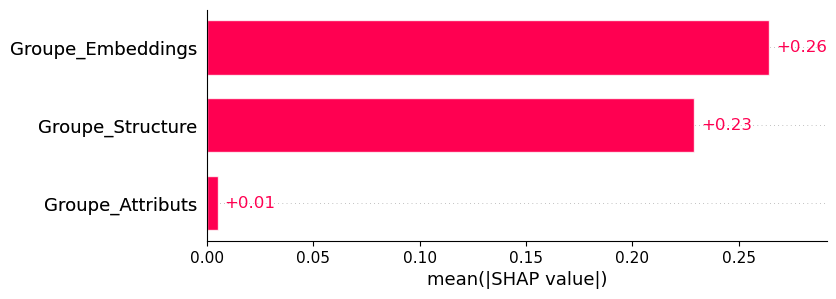

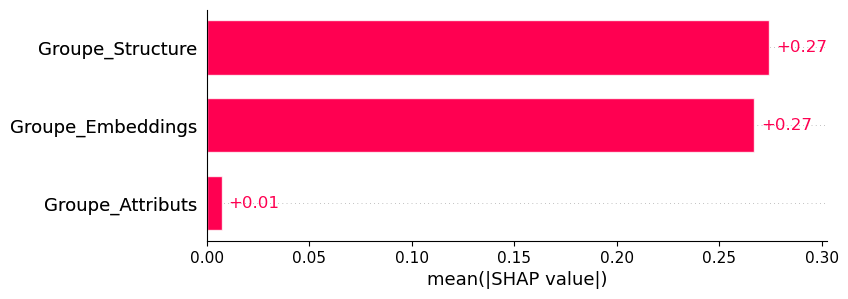

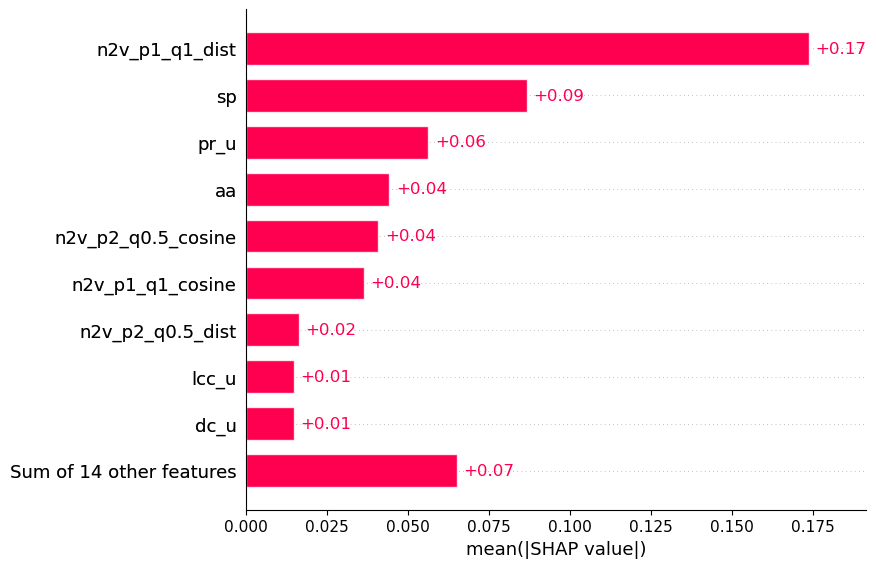


Catégorie                 | Contradiction Ratio 
--------------------------------------------------
Groupe_Structure          | 0.16

Groupe_Attributs          | 0.33

Groupe_Embeddings         | 0.016



In [15]:
gp.evaluate(shap_expl = "shap_explainer_Airports.joblib")